In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [3]:
df = pd.read_csv(
    "urlset.csv",
    encoding="latin1",
    low_memory=False,
    on_bad_lines="skip"
)


print("Dataset shape:", df.shape)
df.head()

Dataset shape: (96005, 14)


,domain,ranking,mld_res,mld.ps_res,card_rem,ratio_Rrem,ratio_Arem,jaccard_RR,jaccard_RA,jaccard_AR,jaccard_AA,jaccard_ARrd,jaccard_ARrem,label
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,10000000,1.0,0.0,18.0,107.611111,107.277778,0.0,0.0,0.0,0.0,0.8,0.795729,1.0
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,10000000,0.0,0.0,11.0,150.636364,152.272727,0.0,0.0,0.0,0.0,0,0.768577,1.0
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,10000000,0.0,0.0,14.0,73.500000,72.642857,0.0,0.0,0.0,0.0,0,0.726582,1.0
3,mail.printakid.com/www.online.americanexpress....,10000000,0.0,0.0,6.0,562.000000,590.666667,0.0,0.0,0.0,0.0,0,0.85964,1.0
4,thewhiskeydregs.com/wp-content/themes/widescre...,10000000,0.0,0.0,8.0,29.000000,24.125000,0.0,0.0,0.0,0.0,0,0.748971,1.0


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96005 entries, 0 to 96004
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   domain         96005 non-null  object 
 1   ranking        95953 non-null  object 
 2   mld_res        95935 non-null  object 
 3   mld.ps_res     95924 non-null  object 
 4   card_rem       95923 non-null  float64
 5   ratio_Rrem     95923 non-null  float64
 6   ratio_Arem     95923 non-null  float64
 7   jaccard_RR     95922 non-null  float64
 8   jaccard_RA     95921 non-null  float64
 9   jaccard_AR     95920 non-null  float64
 10  jaccard_AA     95919 non-null  float64
 11  jaccard_ARrd   95919 non-null  object 
 12  jaccard_ARrem  95917 non-null  object 
 13  label          95913 non-null  float64
dtypes: float64(8), object(6)
memory usage: 10.3+ MB
None


In [5]:
print(df.isnull().sum())

domain            0
ranking          52
mld_res          70
mld.ps_res       81
card_rem         82
ratio_Rrem       82
ratio_Arem       82
jaccard_RR       83
jaccard_RA       84
jaccard_AR       85
jaccard_AA       86
jaccard_ARrd     86
jaccard_ARrem    88
label            92
dtype: int64


In [6]:
print(df["label"].value_counts())

label
0.0    48009
1.0    47904
Name: count, dtype: int64


In [7]:
features = [
    "ranking",
    "mld_res",
    "mld.ps_res",
    "card_rem",
    "ratio_Rrem",
    "ratio_Arem",
    "jaccard_RR",
    "jaccard_RA",
    "jaccard_AR",
    "jaccard_AA",
    "jaccard_ARrd",
    "jaccard_ARrem"
]

X = df[features]
y = df["label"]

In [8]:
X = X.apply(pd.to_numeric, errors="coerce")
y = pd.to_numeric(y, errors="coerce")


In [9]:
data = pd.concat([X, y], axis=1)

data = data.dropna(subset=["label"])

X = data[features]
y = data["label"].astype(int)

X = X.fillna(X.median())

print("Final dataset shape:", X.shape)

Final dataset shape: (95913, 12)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 76730
Testing samples: 19183


In [11]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [12]:
model_1 = Sequential()

model_1.add(Dense(32, activation="relu", input_shape=(X_train.shape[1],)))
model_1.add(Dense(16, activation="relu"))
model_1.add(Dense(1, activation="sigmoid"))

model_1.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_1.summary()

C:\Users\admin\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 961 (3.75 KB)

 Trainable params: 961 (3.75 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history_1 = model_1.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
1919/1919 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.8080 - loss: 0.4297 - val_accuracy: 0.8419 - val_loss: 0.3510
Epoch 2/20
1919/1919 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8427 - loss: 0.3494 - val_accuracy: 0.8439 - val_loss: 0.3384
Epoch 3/20
1919/1919 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8463 - loss: 0.3359 - val_accuracy: 0.8519 - val_loss: 0.3403
Epoch 4/20
1919/1919 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8572 - loss: 0.3264 - val_accuracy: 0.8627 - val_loss: 0.3196
Epoch 5/20
1919/1919 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8606 - loss: 0.3192 - val_accuracy: 0.8635 - val_loss: 0.3153
Epoch 6/20
1919/1919 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8676 - loss: 0.3130 - val_accuracy: 0.8626 - val_loss: 0.3119
Epoch 7/20
1919/1919 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8637 - loss: 0.3108 - val_accuracy: 0.8669 - val_loss: 0.3073
Epoch 8/20
1919/1919 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8683 - loss: 0.3074 -

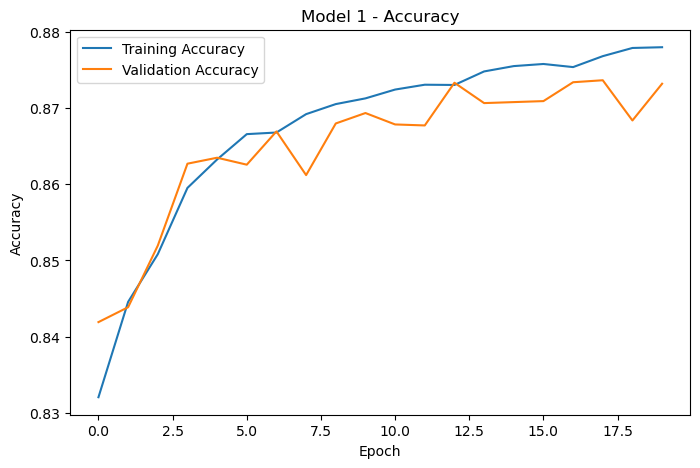

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(history_1.history["accuracy"], label="Training Accuracy")
plt.plot(history_1.history["val_accuracy"], label="Validation Accuracy")

plt.title("Model 1 - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

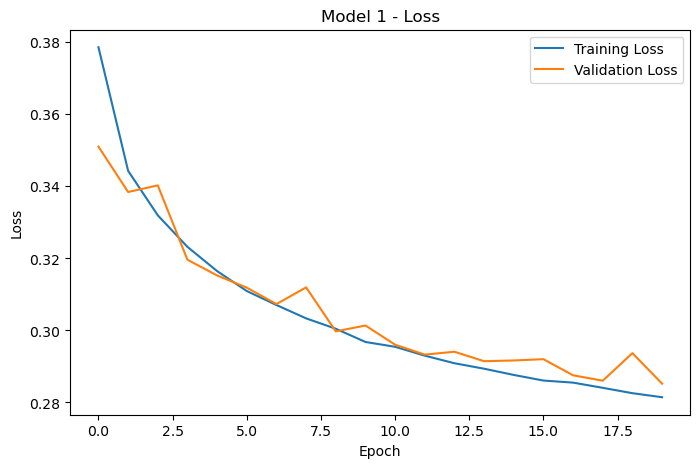

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(history_1.history["loss"], label="Training Loss")
plt.plot(history_1.history["val_loss"], label="Validation Loss")

plt.title("Model 1 - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [16]:
probability_1 = model_1.predict(X_test)

prediction_1 = (probability_1 >= 0.5).astype(int).flatten()

600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


In [18]:
accuracy_1 = accuracy_score(y_test, prediction_1)
precision_1 = precision_score(y_test, prediction_1)
recall_1 = recall_score(y_test, prediction_1)
f1_1 = f1_score(y_test, prediction_1)

print("Model 1 Results")
print("Accuracy :", accuracy_1)
print("Precision:", precision_1)
print("Recall   :", recall_1)
print("F1-Score :", f1_1)

Model 1 Results
Accuracy : 0.8743679299379659
Precision: 0.8936216928312658
Recall   : 0.8495981630309989
F1-Score : 0.8710540395933655


In [19]:
model_2 = Sequential()

model_2.add(Dense(64, activation="relu", input_shape=(X_train.shape[1],)))
model_2.add(Dense(32, activation="relu"))
model_2.add(Dense(1, activation="sigmoid"))

model_2.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_2.summary()

C:\Users\admin\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,945 (11.50 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
history_2 = model_2.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
1919/1919 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.8263 - loss: 0.3890 - val_accuracy: 0.8506 - val_loss: 0.3388
Epoch 2/20
1919/1919 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8455 - loss: 0.3381 - val_accuracy: 0.8527 - val_loss: 0.3250
Epoch 3/20
1919/1919 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8603 - loss: 0.3205 - val_accuracy: 0.8534 - val_loss: 0.3164
Epoch 4/20
1919/1919 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8671 - loss: 0.3081 - val_accuracy: 0.8654 - val_loss: 0.3047
Epoch 5/20
1919/1919 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8691 - loss: 0.3009 - val_accuracy: 0.8673 - val_loss: 0.3006
Epoch 6/20
1919/1919 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8731 - loss: 0.2946 - val_accuracy: 0.8698 - val_loss: 0.2940
Epoch 7/20
1919/1919 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8753 - loss: 0.2888 - val_accuracy: 0.8693 - val_loss: 0.2924
Epoch 8/20
1919/1919 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8749 - loss: 0.2865 -

In [21]:
probability_2 = model_2.predict(X_test)

prediction_2 = (probability_2 >= 0.5).astype(int).flatten()

600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [23]:
accuracy_2 = accuracy_score(y_test, prediction_2)
precision_2 = precision_score(y_test, prediction_2)
recall_2 = recall_score(y_test, prediction_2)
f1_2 = f1_score(y_test, prediction_2)

print("Model 2 Results")
print("Accuracy :", accuracy_2)
print("Precision:", precision_2)
print("Recall   :", recall_2)
print("F1-Score :", f1_2)

Model 2 Results
Accuracy : 0.8875045613303446
Precision: 0.9094318808604522
Recall   : 0.8604529798559649
F1-Score : 0.8842647216561192


In [24]:
model_3 = Sequential()

model_3.add(Dense(64, activation="relu", input_shape=(X_train.shape[1],)))
model_3.add(Dense(32, activation="relu"))
model_3.add(Dense(1, activation="sigmoid"))

model_3.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_3.summary()

C:\Users\admin\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,945 (11.50 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
history_3 = model_3.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
1919/1919 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.7648 - loss: 0.4969 - val_accuracy: 0.8414 - val_loss: 0.3683
Epoch 2/20
1919/1919 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8408 - loss: 0.3626 - val_accuracy: 0.8426 - val_loss: 0.3573
Epoch 3/20
1919/1919 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8421 - loss: 0.3572 - val_accuracy: 0.8451 - val_loss: 0.3529
Epoch 4/20
1919/1919 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8433 - loss: 0.3505 - val_accuracy: 0.8436 - val_loss: 0.3487
Epoch 5/20
1919/1919 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8471 - loss: 0.3497 - val_accuracy: 0.8466 - val_loss: 0.3460
Epoch 6/20
1919/1919 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8490 - loss: 0.3425 - val_accuracy: 0.8476 - val_loss: 0.3438
Epoch 7/20
1919/1919 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8478 - loss: 0.3415 - val_accuracy: 0.8491 - val_loss: 0.3402
Epoch 8/20
1919/1919 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8504 - loss: 0.3356

In [26]:
probability_3 = model_3.predict(X_test)

prediction_3 = (probability_3 >= 0.5).astype(int).flatten()

600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [28]:
accuracy_3 = accuracy_score(y_test, prediction_3)
precision_3 = precision_score(y_test, prediction_3)
recall_3 = recall_score(y_test, prediction_3)
f1_3 = f1_score(y_test, prediction_3)

print("Model 3 Results")
print("Accuracy :", accuracy_3)
print("Precision:", precision_3)
print("Recall   :", recall_3)
print("F1-Score :", f1_3)

Model 3 Results
Accuracy : 0.8607621331387165
Precision: 0.8764436696448028
Recall   : 0.8395783321156456
F1-Score : 0.8576150114611653


In [29]:
model_4 = Sequential()

model_4.add(Dense(64, activation="relu", input_shape=(X_train.shape[1],)))
model_4.add(Dense(32, activation="relu"))
model_4.add(Dense(1, activation="sigmoid"))

model_4.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_4 = model_4.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=30,
    batch_size=64,
    verbose=1
)

Epoch 1/30


C:\Users\admin\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


960/960 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8121 - loss: 0.4085 - val_accuracy: 0.8469 - val_loss: 0.3452
Epoch 2/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8499 - loss: 0.3365 - val_accuracy: 0.8520 - val_loss: 0.3299
Epoch 3/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8559 - loss: 0.3228 - val_accuracy: 0.8621 - val_loss: 0.3197
Epoch 4/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8620 - loss: 0.3199 - val_accuracy: 0.8645 - val_loss: 0.3139
Epoch 5/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8709 - loss: 0.3023 - val_accuracy: 0.8693 - val_loss: 0.3072
Epoch 6/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8736 - loss: 0.2991 - val_accuracy: 0.8703 - val_loss: 0.3031
Epoch 7/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8744 - loss: 0.2942 - val_accuracy: 0.8715 - val_loss: 0.2987
Epoch 8/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8755 - loss: 0.2945 - val_accuracy: 0.8724 - val_

In [30]:
probability_4 = model_4.predict(X_test)

prediction_4 = (probability_4 >= 0.5).astype(int).flatten()

600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [32]:
accuracy_4 = accuracy_score(y_test, prediction_4)
precision_4 = precision_score(y_test, prediction_4)
recall_4 = recall_score(y_test, prediction_4)
f1_4 = f1_score(y_test, prediction_4)

print("Model 4 Results")
print("Accuracy :", accuracy_4)
print("Precision:", precision_4)
print("Recall   :", recall_4)
print("F1-Score :", f1_4)

Model 4 Results
Accuracy : 0.8885992806130428
Precision: 0.90482923645856
Recall   : 0.8682809727585847
F1-Score : 0.8861784287616511


In [33]:
results = pd.DataFrame({
    "Model": [
        "Model 1 - Baseline",
        "Model 2 - More Neurons",
        "Model 3 - Lower Learning Rate",
        "Model 4 - Batch Size & Epochs"
    ],
    
    "Accuracy": [
        accuracy_1,
        accuracy_2,
        accuracy_3,
        accuracy_4
    ],
    
    "Precision": [
        precision_1,
        precision_2,
        precision_3,
        precision_4
    ],
    
    "Recall": [
        recall_1,
        recall_2,
        recall_3,
        recall_4
    ],
    
    "F1-Score": [
        f1_1,
        f1_2,
        f1_3,
        f1_4
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-Score
0,Model 1 - Baseline,0.874368,0.893622,0.849598,0.871054
1,Model 2 - More Neurons,0.887505,0.909432,0.860453,0.884265
2,Model 3 - Lower Learning Rate,0.860762,0.876444,0.839578,0.857615
3,Model 4 - Batch Size & Epochs,0.888599,0.904829,0.868281,0.886178


In [34]:
final_prediction = prediction_4

cm = confusion_matrix(y_test, final_prediction)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[8727  875]
 [1262 8319]]


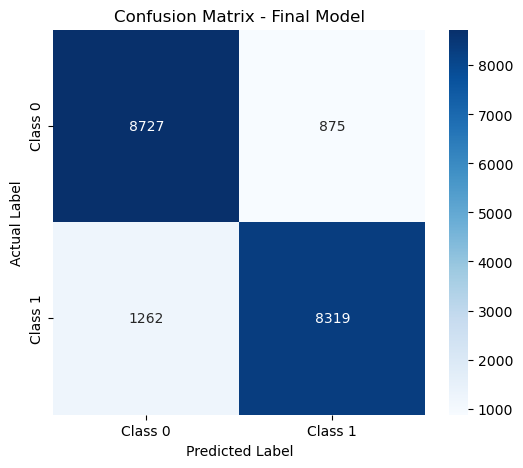

In [35]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Class 0", "Class 1"],
    yticklabels=["Class 0", "Class 1"]
)

plt.title("Confusion Matrix - Final Model")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [36]:
print("Final Model Performance")

print("Accuracy :", accuracy_score(y_test, final_prediction))
print("Precision:", precision_score(y_test, final_prediction))
print("Recall   :", recall_score(y_test, final_prediction))
print("F1-Score :", f1_score(y_test, final_prediction))

Final Model Performance
Accuracy : 0.8885992806130428
Precision: 0.90482923645856
Recall   : 0.8682809727585847
F1-Score : 0.8861784287616511


In [37]:
print(classification_report(y_test, final_prediction))

              precision    recall  f1-score   support

           0       0.87      0.91      0.89      9602
           1       0.90      0.87      0.89      9581

    accuracy                           0.89     19183
   macro avg       0.89      0.89      0.89     19183
weighted avg       0.89      0.89      0.89     19183



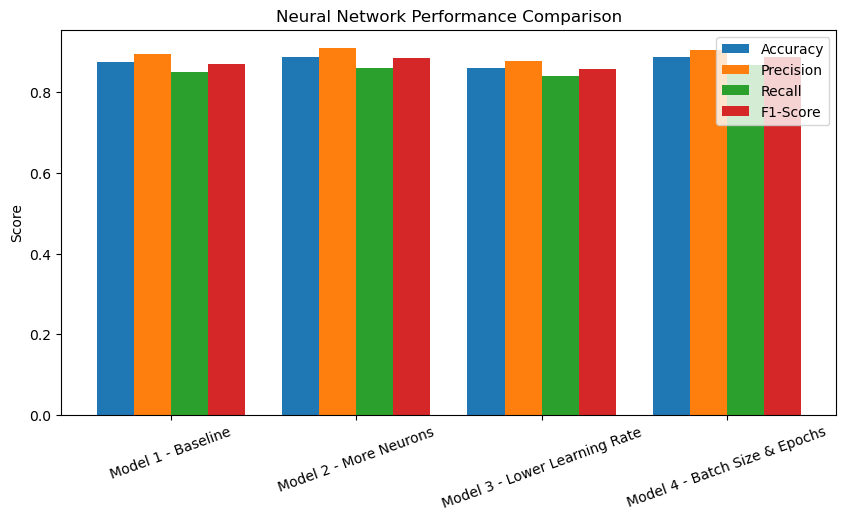

In [38]:
plt.figure(figsize=(10, 5))

x = np.arange(len(results))
width = 0.2

plt.bar(x - 1.5*width, results["Accuracy"], width, label="Accuracy")
plt.bar(x - 0.5*width, results["Precision"], width, label="Precision")
plt.bar(x + 0.5*width, results["Recall"], width, label="Recall")
plt.bar(x + 1.5*width, results["F1-Score"], width, label="F1-Score")

plt.xticks(x, results["Model"], rotation=20)
plt.ylabel("Score")
plt.title("Neural Network Performance Comparison")
plt.legend()

plt.show()